In [1]:
# imports and read data
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
import geopandas as gpd
import seaborn as sns
import sys


df = pd.read_csv("Crime_Data_from_2020_to_Present.csv", encoding="latin-1")

In [2]:
# display all columns
pd.set_option('display.max_columns', None)
df.head()

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,190326475,3/1/2020 0:00,3/1/2020 0:00,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,NaN,0,M,O,101.0,STREET,NaN,NaN,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,200106753,2/9/2020 0:00,2/8/2020 0:00,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,1822 1402 0344,47,M,O,128.0,BUS STOP/LAYOVER (ALSO QUERY 124),NaN,NaN,IC,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,200320258,11/11/2020 0:00,11/4/2020 0:00,1700,3,Southwest,356,1,480,BIKE - STOLEN,0344 1251,19,X,X,502.0,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",NaN,NaN,IC,Invest Cont,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002
3,200907217,5/10/2023 0:00,3/10/2020 0:00,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),0325 1501,19,M,O,405.0,CLOTHING STORE,NaN,NaN,IC,Invest Cont,343.0,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
4,200412582,9/9/2020 0:00,9/9/2020 0:00,630,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,NaN,0,NaN,NaN,101.0,STREET,NaN,NaN,IC,Invest Cont,510.0,NaN,NaN,NaN,200 E AVENUE 28,NaN,34.0820,-118.2130


In [3]:
# summary of data
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1005198 entries, 0 to 1005197
Data columns (total 28 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   DR_NO           1005198 non-null  int64  
 1   Date Rptd       1005198 non-null  object 
 2   DATE OCC        1005198 non-null  object 
 3   TIME OCC        1005198 non-null  int64  
 4   AREA            1005198 non-null  int64  
 5   AREA NAME       1005198 non-null  object 
 6   Rpt Dist No     1005198 non-null  int64  
 7   Part 1-2        1005198 non-null  int64  
 8   Crm Cd          1005198 non-null  int64  
 9   Crm Cd Desc     1005198 non-null  object 
 10  Mocodes         853438 non-null   object 
 11  Vict Age        1005198 non-null  int64  
 12  Vict Sex        860416 non-null   object 
 13  Vict Descent    860404 non-null   object 
 14  Premis Cd       1005182 non-null  float64
 15  Premis Desc     1004610 non-null  object 
 16  Weapon Used Cd  327280 non-null   fl

,DR_NO,TIME OCC,AREA,Rpt Dist No,Part 1-2,Crm Cd,Vict Age,Premis Cd,Weapon Used Cd,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LAT,LON
count,1.005198e+06,1.005198e+06,1.005198e+06,1.005198e+06,1.005198e+06,1.005198e+06,1.005198e+06,1.005182e+06,327280.000000,1.005187e+06,69159.000000,2314.000000,64.00000,1.005198e+06,1.005198e+06
mean,2.202277e+08,1.339911e+03,1.069098e+01,1.115556e+03,1.400283e+00,5.001458e+02,2.891253e+01,3.056189e+02,363.953651,4.999063e+02,958.105221,984.015990,991.21875,3.399820e+01,-1.180909e+02
std,1.320282e+07,6.510531e+02,6.110385e+00,6.111733e+02,4.899559e-01,2.052635e+02,2.199382e+01,2.193160e+02,123.736081,2.050640e+02,110.354136,52.350982,27.06985,1.610549e+00,5.581812e+00
min,8.170000e+02,1.000000e+00,1.000000e+00,1.010000e+02,1.000000e+00,1.100000e+02,-4.000000e+00,1.010000e+02,101.000000,1.100000e+02,210.000000,310.000000,821.00000,0.000000e+00,-1.186676e+02
25%,2.106169e+08,9.000000e+02,5.000000e+00,5.870000e+02,1.000000e+00,3.310000e+02,0.000000e+00,1.010000e+02,311.000000,3.310000e+02,998.000000,998.000000,998.00000,3.401470e+01,-1.184305e+02
50%,2.209160e+08,1.420000e+03,1.100000e+01,1.139000e+03,1.000000e+00,4.420000e+02,3.000000e+01,2.030000e+02,400.000000,4.420000e+02,998.000000,998.000000,998.00000,3.405890e+01,-1.183225e+02
75%,2.311105e+08,1.900000e+03,1.600000e+01,1.613000e+03,2.000000e+00,6.260000e+02,4.400000e+01,5.010000e+02,400.000000,6.260000e+02,998.000000,998.000000,998.00000,3.416490e+01,-1.182739e+02
max,2.521041e+08,2.359000e+03,2.100000e+01,2.199000e+03,2.000000e+00,9.560000e+02,1.200000e+02,9.760000e+02,516.000000,9.560000e+02,999.000000,999.000000,999.00000,3.433430e+01,0.000000e+00


The victim age feature seems to have invalid data, the minimum value is -4. LAT has 0 as min and LON has 0 as max, which are not in LA.

In [4]:
# number of missing values
df.isnull().sum()


DR_NO                   0
Date Rptd               0
DATE OCC                0
TIME OCC                0
AREA                    0
AREA NAME               0
Rpt Dist No             0
Part 1-2                0
Crm Cd                  0
Crm Cd Desc             0
Mocodes            151760
Vict Age                0
Vict Sex           144782
Vict Descent       144794
Premis Cd              16
Premis Desc           588
Weapon Used Cd     677918
Weapon Desc        677918
Status                  1
Status Desc             0
Crm Cd 1               11
Crm Cd 2           936039
Crm Cd 3          1002884
Crm Cd 4          1005134
LOCATION                0
Cross Street       850955
LAT                     0
LON                     0
dtype: int64

In [5]:
# percentage missing values
missing_percent = df.isnull().mean() * 100
missing_percent.sort_values(ascending=False)

Crm Cd 4          99.993633
Crm Cd 3          99.769797
Crm Cd 2          93.119863
Cross Street      84.655461
Weapon Used Cd    67.441240
Weapon Desc       67.441240
Mocodes           15.097523
Vict Descent      14.404525
Vict Sex          14.403331
Premis Desc        0.058496
Premis Cd          0.001592
Crm Cd 1           0.001094
Status             0.000099
LAT                0.000000
LOCATION           0.000000
Status Desc        0.000000
DR_NO              0.000000
Date Rptd          0.000000
Vict Age           0.000000
Crm Cd Desc        0.000000
Crm Cd             0.000000
Part 1-2           0.000000
Rpt Dist No        0.000000
AREA NAME          0.000000
AREA               0.000000
TIME OCC           0.000000
DATE OCC           0.000000
LON                0.000000
dtype: float64

In [6]:
# total number of missing values
df.isnull().sum().sum()

5592800

In [7]:
# number of duplicates
df.duplicated().sum()

0

We see that the additional crime codes are missing a lot of values, so most of the time there is only one crime and not multiple. While the missing weapons data indicate that in most crimes no weapon was involved. Around 14.4 % of the crimes are missing descent and sex information about the victim. Also cross Street and modus operandi codes have a lot of missing values.

There are no duplicates.



In [8]:
# number of crimes with LAT or LAN 0
total_rows = len(df)
zero_coord_rows = ((df["LAT"] == 0) | (df["LON"] == 0)).sum()
print(f"Total rows: {total_rows}")
print(
    f"Rows with 0 latitude or longitude: {zero_coord_rows} ({zero_coord_rows / total_rows:.2%})"
)


Total rows: 1005198
Rows with 0 latitude or longitude: 2240 (0.22%)


In [9]:
# drops invalid LAT and LON
df = df[~((df["LAT"] == 0) | (df["LON"] == 0))]
df = df.reset_index(drop=True)

In [10]:
# Load area data
divisions = gpd.read_file("lapd-divisions.geojson")
divisions.columns

Index(['OBJECTID', 'APREC', 'PREC', 'AREA', 'PERIMETER', 'geometry'], dtype='object')

In [11]:
# crime data to GeoDataFrame data structure
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["LON"], df["LAT"]),
    crs="EPSG:4326"
)

In [12]:
# map area names of the area dataset to same form as in the crime dataset
area_mapping = {
    "WILSHIRE": "Wilshire",
    "CENTRAL": "Central",
    "SOUTHWEST": "Southwest",
    "VAN NUYS": "Van Nuys",
    "HOLLENBECK": "Hollenbeck",
    "RAMPART": "Rampart",
    "NEWTON": "Newton",
    "NORTHEAST": "Northeast",
    "77TH STREET": "77th Street",
    "HOLLYWOOD": "Hollywood",
    "HARBOR": "Harbor",
    "WEST VALLEY": "West Valley",
    "WEST LOS ANGELES": "West LA",
    "NORTH HOLLYWOOD": "N Hollywood",
    "PACIFIC": "Pacific",
    "DEVONSHIRE": "Devonshire",
    "MISSION": "Mission",
    "SOUTHEAST": "Southeast",
    "OLYMPIC": "Olympic",
    "FOOTHILL": "Foothill",
    "TOPANGA": "Topanga"
}

divisions["AREA_NAME_CLEAN"] = divisions["APREC"].map(area_mapping)

In [13]:
# Spatial join of two GeoDataFrames, check whether crime locations are actually in areas.
joined = gpd.sjoin(
    gdf,
    divisions[["AREA_NAME_CLEAN", "PREC", "geometry"]],
    how="left",
    predicate="intersects"
)

In [14]:
# remove crimes outside of areas.
print("Crimes outside of LA:", joined["AREA_NAME_CLEAN"].isna().sum())
df = joined.dropna(subset=["AREA_NAME_CLEAN"]).copy()

Crimes outside of LA: 3981


In [15]:
# Crimes with wrong area 
mismatch = (
    (df["AREA NAME"] != df["AREA_NAME_CLEAN"]) |
    (df["AREA"] != df["PREC"])
)
print("Mismatches:", mismatch.sum())

Mismatches: 8959


In [16]:
# Add correct area to crimes
df.loc[mismatch, "AREA NAME"] = df.loc[mismatch, "AREA_NAME_CLEAN"]
df.loc[mismatch, "AREA"] = df.loc[mismatch, "PREC"]

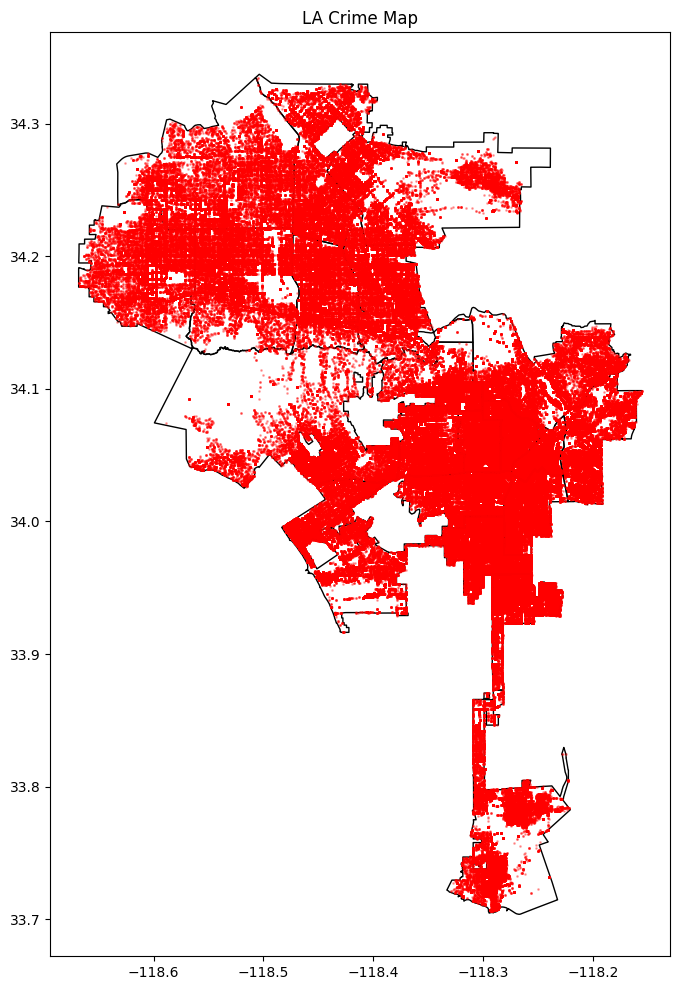

In [17]:
fig, ax = plt.subplots(figsize=(12, 12))

# LA area
divisions.plot(
    ax=ax,
    edgecolor="black",
    facecolor="none",
    linewidth=1
)
# Crimes
gdf.plot(
    ax=ax,
    color="red",
    markersize=1,
    alpha=0.3
)

plt.title("LA Crime Map")
plt.show()

In [18]:
# remove help features
df = df.drop(columns=[
    "index_right",
    "AREA_NAME_CLEAN",
    "PREC",
    "geometry"
], errors="ignore")

In [19]:
# crimes left
print("Crimes left:", len(df))

Crimes left: 998977


In [20]:
df

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON
0,190326475,3/1/2020 0:00,3/1/2020 0:00,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,NaN,0,M,O,101.0,STREET,NaN,NaN,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506
1,200106753,2/9/2020 0:00,2/8/2020 0:00,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,1822 1402 0344,47,M,O,128.0,BUS STOP/LAYOVER (ALSO QUERY 124),NaN,NaN,IC,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628
2,200320258,11/11/2020 0:00,11/4/2020 0:00,1700,3,Southwest,356,1,480,BIKE - STOLEN,0344 1251,19,X,X,502.0,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",NaN,NaN,IC,Invest Cont,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002
3,200907217,5/10/2023 0:00,3/10/2020 0:00,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),0325 1501,19,M,O,405.0,CLOTHING STORE,NaN,NaN,IC,Invest Cont,343.0,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387
4,200412582,9/9/2020 0:00,9/9/2020 0:00,630,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,NaN,0,NaN,NaN,101.0,STREET,NaN,NaN,IC,Invest Cont,510.0,NaN,NaN,NaN,200 E AVENUE 28,NaN,34.0820,-118.2130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1002953,250304214,2/23/2025 0:00,2/21/2025 0:00,1530,3,Southwest,358,1,510,VEHICLE - STOLEN,NaN,0,NaN,NaN,101.0,STREET,NaN,NaN,IC,Invest Cont,510.0,NaN,NaN,NaN,3600 MCCLINTOCK AV,NaN,34.0212,-118.2895
1002954,250304203,2/20/2025 0:00,2/13/2025 0:00,2100,3,Southwest,325,1,522,"VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, B...",NaN,0,NaN,NaN,108.0,PARKING LOT,NaN,NaN,IC,Invest Cont,522.0,NaN,NaN,NaN,2600 ELLENDALE PL,NaN,34.0307,-118.2923
1002955,250504051,1/14/2025 0:00,1/14/2025 0:00,1250,5,Harbor,509,1,210,ROBBERY,1822 0344 1259,15,F,H,721.0,HIGH SCHOOL,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,210.0,NaN,NaN,NaN,24300 WESTERN AV,NaN,33.8046,-118.3074
1002956,251604136,2/27/2025 0:00,2/27/2025 0:00,1550,16,Foothill,1664,1,510,VEHICLE - STOLEN,NaN,0,NaN,NaN,101.0,STREET,NaN,NaN,AA,Adult Arrest,510.0,NaN,NaN,NaN,11900 SHELDON ST,NaN,34.2404,-118.3922


As noticed earlier, the dataset had a lot of coordinates with LAT or LON as 0, so we deleted these records, they are not in LA. After that we found that there were more records outside of LA, around 3981 records, which we removed. Also there were 8959 records with the wrong area according to their coordinates, so we corrected the area names and number.

<Axes: >

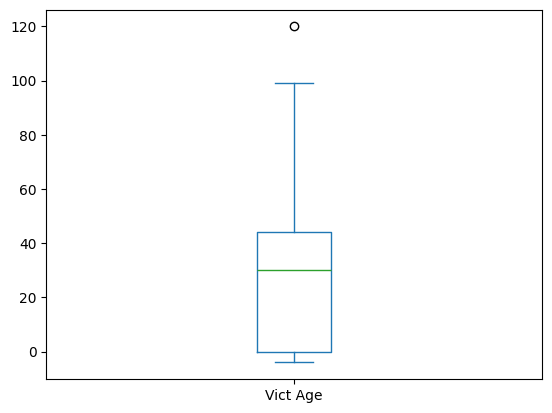

In [21]:
# plot age values 
df.plot(kind="box", y="Vict Age")


In [22]:
# unique values
for col in df.columns:
    print(f"\nColumn: {col}")
    print(df[col].unique())


Column: DR_NO
[190326475 200106753 200320258 ... 250504051 251604136 251904210]

Column: Date Rptd
['3/1/2020 0:00' '2/9/2020 0:00' '11/11/2020 0:00' ... '2/1/2025 0:00'
 '3/21/2025 0:00' '1/25/2025 0:00']

Column: DATE OCC
['3/1/2020 0:00' '2/8/2020 0:00' '11/4/2020 0:00' ... '3/3/2025 0:00'
 '1/3/2025 0:00' '1/19/2025 0:00']

Column: TIME OCC
[2130 1800 1700 ...  559  818  841]

Column: AREA
[ 7  1  3  9  4  2 13 11 12  6  5 10  8 21 20 15 18 17 14 19 16]

Column: AREA NAME
['Wilshire' 'Central' 'Southwest' 'Van Nuys' 'Hollenbeck' 'Rampart'
 'Newton' 'Northeast' '77th Street' 'Hollywood' 'Harbor' 'West Valley'
 'West LA' 'Topanga' 'Olympic' 'N Hollywood' 'Southeast' 'Devonshire'
 'Pacific' 'Mission' 'Foothill']

Column: Rpt Dist No
[784 182 356 ... 672 709 902]

Column: Part 1-2
[1 2]

Column: Crm Cd
[510 330 480 343 648 310 805 806 946 745 626 210 341 230 354 624 442 662
 900 901 440 740 121 331 888 520 437 668 410 956 930 845 661 420 812 761
 320 753 623 522 820 850 450 627 625 88

In [23]:
# number of unique values
for col in df.columns:
    print(f"\nColumn: {col}")
    print(df[col].nunique())


Column: DR_NO
998977

Column: Date Rptd
1906

Column: DATE OCC
1901

Column: TIME OCC
1439

Column: AREA
21

Column: AREA NAME
21

Column: Rpt Dist No
1202

Column: Part 1-2
2

Column: Crm Cd
140

Column: Crm Cd Desc
140

Column: Mocodes
309503

Column: Vict Age
104

Column: Vict Sex
5

Column: Vict Descent
20

Column: Premis Cd
314

Column: Premis Desc
306

Column: Weapon Used Cd
79

Column: Weapon Desc
79

Column: Status
6

Column: Status Desc
6

Column: Crm Cd 1
142

Column: Crm Cd 2
126

Column: Crm Cd 3
38

Column: Crm Cd 4
6

Column: LOCATION
66335

Column: Cross Street
10370

Column: LAT
5398

Column: LON
4977


Here we can clearly see that the age feature has negative values and there are some records with 0 as latitude or longitude.


<Axes: >

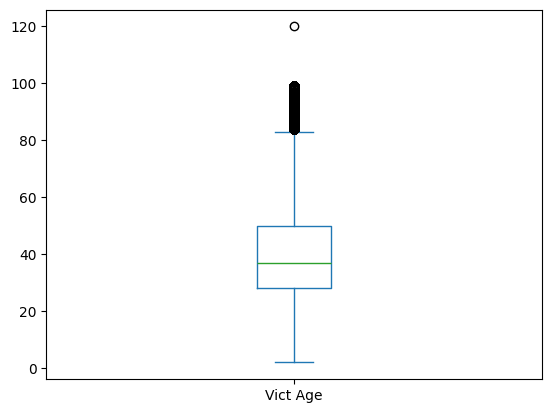

In [24]:
# remove negative age values
df['Vict Age'] = df['Vict Age'].apply(lambda x: np.nan if x <= 0 else x)
df.plot(kind="box", y="Vict Age")

In [25]:
# F - Female M - Male X - Unknown
# Replace missing values and values that do not mean anything with Unknown
df['Vict Sex'] = df['Vict Sex'].replace(['-', 'H'], 'X')
df['Vict Sex'] = df['Vict Sex'].fillna('X')

In [26]:
# Descent Code: A - Other Asian B - Black C - Chinese D - Cambodian F - Filipino G - Guamanian H - Hispanic/Latin/Mexican I - American Indian/Alaskan Native J - Japanese K - Korean L - Laotian O - Other P - Pacific Islander S - Samoan U - Hawaiian V - Vietnamese W - White X - Unknown Z - Asian Indian
# Replace missing values and values that do not mean anything with Unknown
df['Vict Descent'] = df['Vict Descent'].replace(['-'], 'X')
df['Vict Descent'] = df['Vict Descent'].fillna('X')


In [27]:
# make categories human readable
descent_map = {
    'A': "Other Asian",
    'B': "Black",
    'C': "Chinese",
    'D': "Cambodian",
    'F': "Filipino",
    'G': "Guamanian",
    'H': "Hispanic/Latin/Mexican",
    'I': "American Indian/Alaskan Native",
    'J': "Japanese",
    'K': "Korean",
    'L': "Laotian",
    'O': "Other",
    'P': "Pacific Islander",
    'S': "Samoan",
    'U': "Hawaiian",
    'V': "Vietnamese",
    'W': "White",
    'X': "Unknown",
    'Z': "Asian Indian"
}

sex_map = {
    'F': "Female",
    'M': "Male",
    'X': "Unknown",
}

df['Vict Sex Desc'] = df['Vict Sex'].map(sex_map)
df['Vict Descent Desc'] = df['Vict Descent'].map(descent_map)

In [28]:
# dates to standaard datetime format
df['DATE OCC'] = pd.to_datetime(df['DATE OCC'], errors='coerce')
df['Date Rptd'] = pd.to_datetime(df['Date Rptd'], errors='coerce')

In [29]:
# only keep the date
df['Date Rptd'] = df['Date Rptd'].dt.date

In [30]:
# combine date and time
df['DateTime OCC'] = pd.to_datetime(
    df['DATE OCC'].dt.date.astype(str) + ' ' +
    df['TIME OCC'].astype(str).str.zfill(4),
    format='%Y-%m-%d %H%M'
)

In [31]:
code_to_desc = dict(zip(df['Crm Cd'], df['Crm Cd Desc']))

In [32]:
# make crime codes human readable
for col in ['Crm Cd 2','Crm Cd 3','Crm Cd 4']:
    df[col + ' Desc'] = df[col].map(code_to_desc)
    df.loc[df[col].notna() & df[col + ' Desc'].isna(), col + ' Desc'] = 'Other Crime'

In [33]:
# make modus operandi codes human readable
with open("mo_codes.json") as f:
    mo_map = json.load(f)

def translate_mocodes(codes_str):
    if pd.isna(codes_str):
        return np.nan
    codes = str(codes_str).split()
    return "; ".join(mo_map.get(c, c) for c in codes)


df["MO Desc"] = df["Mocodes"].apply(translate_mocodes)

In [34]:
# missing value is the same as no weapon
df['Weapon Desc'] = df['Weapon Desc'].fillna('No Weapon')

In [35]:
df

,DR_NO,Date Rptd,DATE OCC,TIME OCC,AREA,AREA NAME,Rpt Dist No,Part 1-2,Crm Cd,Crm Cd Desc,Mocodes,Vict Age,Vict Sex,Vict Descent,Premis Cd,Premis Desc,Weapon Used Cd,Weapon Desc,Status,Status Desc,Crm Cd 1,Crm Cd 2,Crm Cd 3,Crm Cd 4,LOCATION,Cross Street,LAT,LON,Vict Sex Desc,Vict Descent Desc,DateTime OCC,Crm Cd 2 Desc,Crm Cd 3 Desc,Crm Cd 4 Desc,MO Desc
0,190326475,2020-03-01,2020-03-01,2130,7,Wilshire,784,1,510,VEHICLE - STOLEN,NaN,NaN,M,O,101.0,STREET,NaN,No Weapon,AA,Adult Arrest,510.0,998.0,NaN,NaN,1900 S LONGWOOD AV,NaN,34.0375,-118.3506,Male,Other,2020-03-01 21:30:00,Other Crime,NaN,NaN,NaN
1,200106753,2020-02-09,2020-02-08,1800,1,Central,182,1,330,BURGLARY FROM VEHICLE,1822 1402 0344,47.0,M,O,128.0,BUS STOP/LAYOVER (ALSO QUERY 124),NaN,No Weapon,IC,Invest Cont,330.0,998.0,NaN,NaN,1000 S FLOWER ST,NaN,34.0444,-118.2628,Male,Other,2020-02-08 18:00:00,Other Crime,NaN,NaN,Stranger; Evidence Booked (any crime); Removes...
2,200320258,2020-11-11,2020-11-04,1700,3,Southwest,356,1,480,BIKE - STOLEN,0344 1251,19.0,X,X,502.0,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",NaN,No Weapon,IC,Invest Cont,480.0,NaN,NaN,NaN,1400 W 37TH ST,NaN,34.0210,-118.3002,Unknown,Unknown,2020-11-04 17:00:00,NaN,NaN,NaN,Removes vict property; Victim was a student
3,200907217,2023-05-10,2020-03-10,2037,9,Van Nuys,964,1,343,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),0325 1501,19.0,M,O,405.0,CLOTHING STORE,NaN,No Weapon,IC,Invest Cont,343.0,NaN,NaN,NaN,14000 RIVERSIDE DR,NaN,34.1576,-118.4387,Male,Other,2020-03-10 20:37:00,NaN,NaN,NaN,Took merchandise; Other MO (see rpt)
4,200412582,2020-09-09,2020-09-09,630,4,Hollenbeck,413,1,510,VEHICLE - STOLEN,NaN,NaN,X,X,101.0,STREET,NaN,No Weapon,IC,Invest Cont,510.0,NaN,NaN,NaN,200 E AVENUE 28,NaN,34.0820,-118.2130,Unknown,Unknown,2020-09-09 06:30:00,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1002953,250304214,2025-02-23,2025-02-21,1530,3,Southwest,358,1,510,VEHICLE - STOLEN,NaN,NaN,X,X,101.0,STREET,NaN,No Weapon,IC,Invest Cont,510.0,NaN,NaN,NaN,3600 MCCLINTOCK AV,NaN,34.0212,-118.2895,Unknown,Unknown,2025-02-21 15:30:00,NaN,NaN,NaN,NaN
1002954,250304203,2025-02-20,2025-02-13,2100,3,Southwest,325,1,522,"VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, B...",NaN,NaN,X,X,108.0,PARKING LOT,NaN,No Weapon,IC,Invest Cont,522.0,NaN,NaN,NaN,2600 ELLENDALE PL,NaN,34.0307,-118.2923,Unknown,Unknown,2025-02-13 21:00:00,NaN,NaN,NaN,NaN
1002955,250504051,2025-01-14,2025-01-14,1250,5,Harbor,509,1,210,ROBBERY,1822 0344 1259,15.0,F,H,721.0,HIGH SCHOOL,400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",IC,Invest Cont,210.0,NaN,NaN,NaN,24300 WESTERN AV,NaN,33.8046,-118.3074,Female,Hispanic/Latin/Mexican,2025-01-14 12:50:00,NaN,NaN,NaN,Stranger; Removes vict property; Victim is 14 ...
1002956,251604136,2025-02-27,2025-02-27,1550,16,Foothill,1664,1,510,VEHICLE - STOLEN,NaN,NaN,X,X,101.0,STREET,NaN,No Weapon,AA,Adult Arrest,510.0,NaN,NaN,NaN,11900 SHELDON ST,NaN,34.2404,-118.3922,Unknown,Unknown,2025-02-27 15:50:00,NaN,NaN,NaN,NaN


In [36]:
df.isnull().sum()


DR_NO                     0
Date Rptd                 0
DATE OCC                  0
TIME OCC                  0
AREA                      0
AREA NAME                 0
Rpt Dist No               0
Part 1-2                  0
Crm Cd                    0
Crm Cd Desc               0
Mocodes              150986
Vict Age             267831
Vict Sex                  0
Vict Descent              0
Premis Cd                16
Premis Desc             586
Weapon Used Cd       673770
Weapon Desc               0
Status                    1
Status Desc               0
Crm Cd 1                 11
Crm Cd 2             930254
Crm Cd 3             996668
Crm Cd 4             998913
LOCATION                  0
Cross Street         845828
LAT                       0
LON                       0
Vict Sex Desc             0
Vict Descent Desc         0
DateTime OCC              0
Crm Cd 2 Desc        930254
Crm Cd 3 Desc        996668
Crm Cd 4 Desc        998913
MO Desc              150986
dtype: int64

We removed categories that are not defined or documented in the dataset. Valid codes were mapped to more readable labels. Records with negative age values were removed. Date and time fields were also combined into a single datetime column.

dataset documentation: https://data.lacity.org/Public-Safety/Crime-Data-from-2020-to-2024/2nrs-mtv8/about_data

In [37]:
# remove features that are not needed
# Crm Cd 1 is the same as Crm Cd
df = df.drop(columns=['Date Rptd', 'DATE OCC', 'TIME OCC', 'Crm Cd', 'Status', 'Rpt Dist No',
                      'Crm Cd 1','Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'Cross Street', 'AREA', 'Mocodes', 'MO Desc',
                      'Premis Cd', 'Weapon Used Cd',
                     ])


In [38]:
df

,DR_NO,AREA NAME,Part 1-2,Crm Cd Desc,Vict Age,Vict Sex,Vict Descent,Premis Desc,Weapon Desc,Status Desc,LOCATION,LAT,LON,Vict Sex Desc,Vict Descent Desc,DateTime OCC,Crm Cd 2 Desc,Crm Cd 3 Desc,Crm Cd 4 Desc
0,190326475,Wilshire,1,VEHICLE - STOLEN,NaN,M,O,STREET,No Weapon,Adult Arrest,1900 S LONGWOOD AV,34.0375,-118.3506,Male,Other,2020-03-01 21:30:00,Other Crime,NaN,NaN
1,200106753,Central,1,BURGLARY FROM VEHICLE,47.0,M,O,BUS STOP/LAYOVER (ALSO QUERY 124),No Weapon,Invest Cont,1000 S FLOWER ST,34.0444,-118.2628,Male,Other,2020-02-08 18:00:00,Other Crime,NaN,NaN
2,200320258,Southwest,1,BIKE - STOLEN,19.0,X,X,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",No Weapon,Invest Cont,1400 W 37TH ST,34.0210,-118.3002,Unknown,Unknown,2020-11-04 17:00:00,NaN,NaN,NaN
3,200907217,Van Nuys,1,SHOPLIFTING-GRAND THEFT ($950.01 & OVER),19.0,M,O,CLOTHING STORE,No Weapon,Invest Cont,14000 RIVERSIDE DR,34.1576,-118.4387,Male,Other,2020-03-10 20:37:00,NaN,NaN,NaN
4,200412582,Hollenbeck,1,VEHICLE - STOLEN,NaN,X,X,STREET,No Weapon,Invest Cont,200 E AVENUE 28,34.0820,-118.2130,Unknown,Unknown,2020-09-09 06:30:00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1002953,250304214,Southwest,1,VEHICLE - STOLEN,NaN,X,X,STREET,No Weapon,Invest Cont,3600 MCCLINTOCK AV,34.0212,-118.2895,Unknown,Unknown,2025-02-21 15:30:00,NaN,NaN,NaN
1002954,250304203,Southwest,1,"VEHICLE, STOLEN - OTHER (MOTORIZED SCOOTERS, B...",NaN,X,X,PARKING LOT,No Weapon,Invest Cont,2600 ELLENDALE PL,34.0307,-118.2923,Unknown,Unknown,2025-02-13 21:00:00,NaN,NaN,NaN
1002955,250504051,Harbor,1,ROBBERY,15.0,F,H,HIGH SCHOOL,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",Invest Cont,24300 WESTERN AV,33.8046,-118.3074,Female,Hispanic/Latin/Mexican,2025-01-14 12:50:00,NaN,NaN,NaN
1002956,251604136,Foothill,1,VEHICLE - STOLEN,NaN,X,X,STREET,No Weapon,Adult Arrest,11900 SHELDON ST,34.2404,-118.3922,Unknown,Unknown,2025-02-27 15:50:00,NaN,NaN,NaN


/var/folders/3x/zl8pfg9d5sgbq9nghfmjszsr0000gn/T/ipykernel_7184/2851119393.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_crimes.values, y=top_crimes.index, palette="viridis")


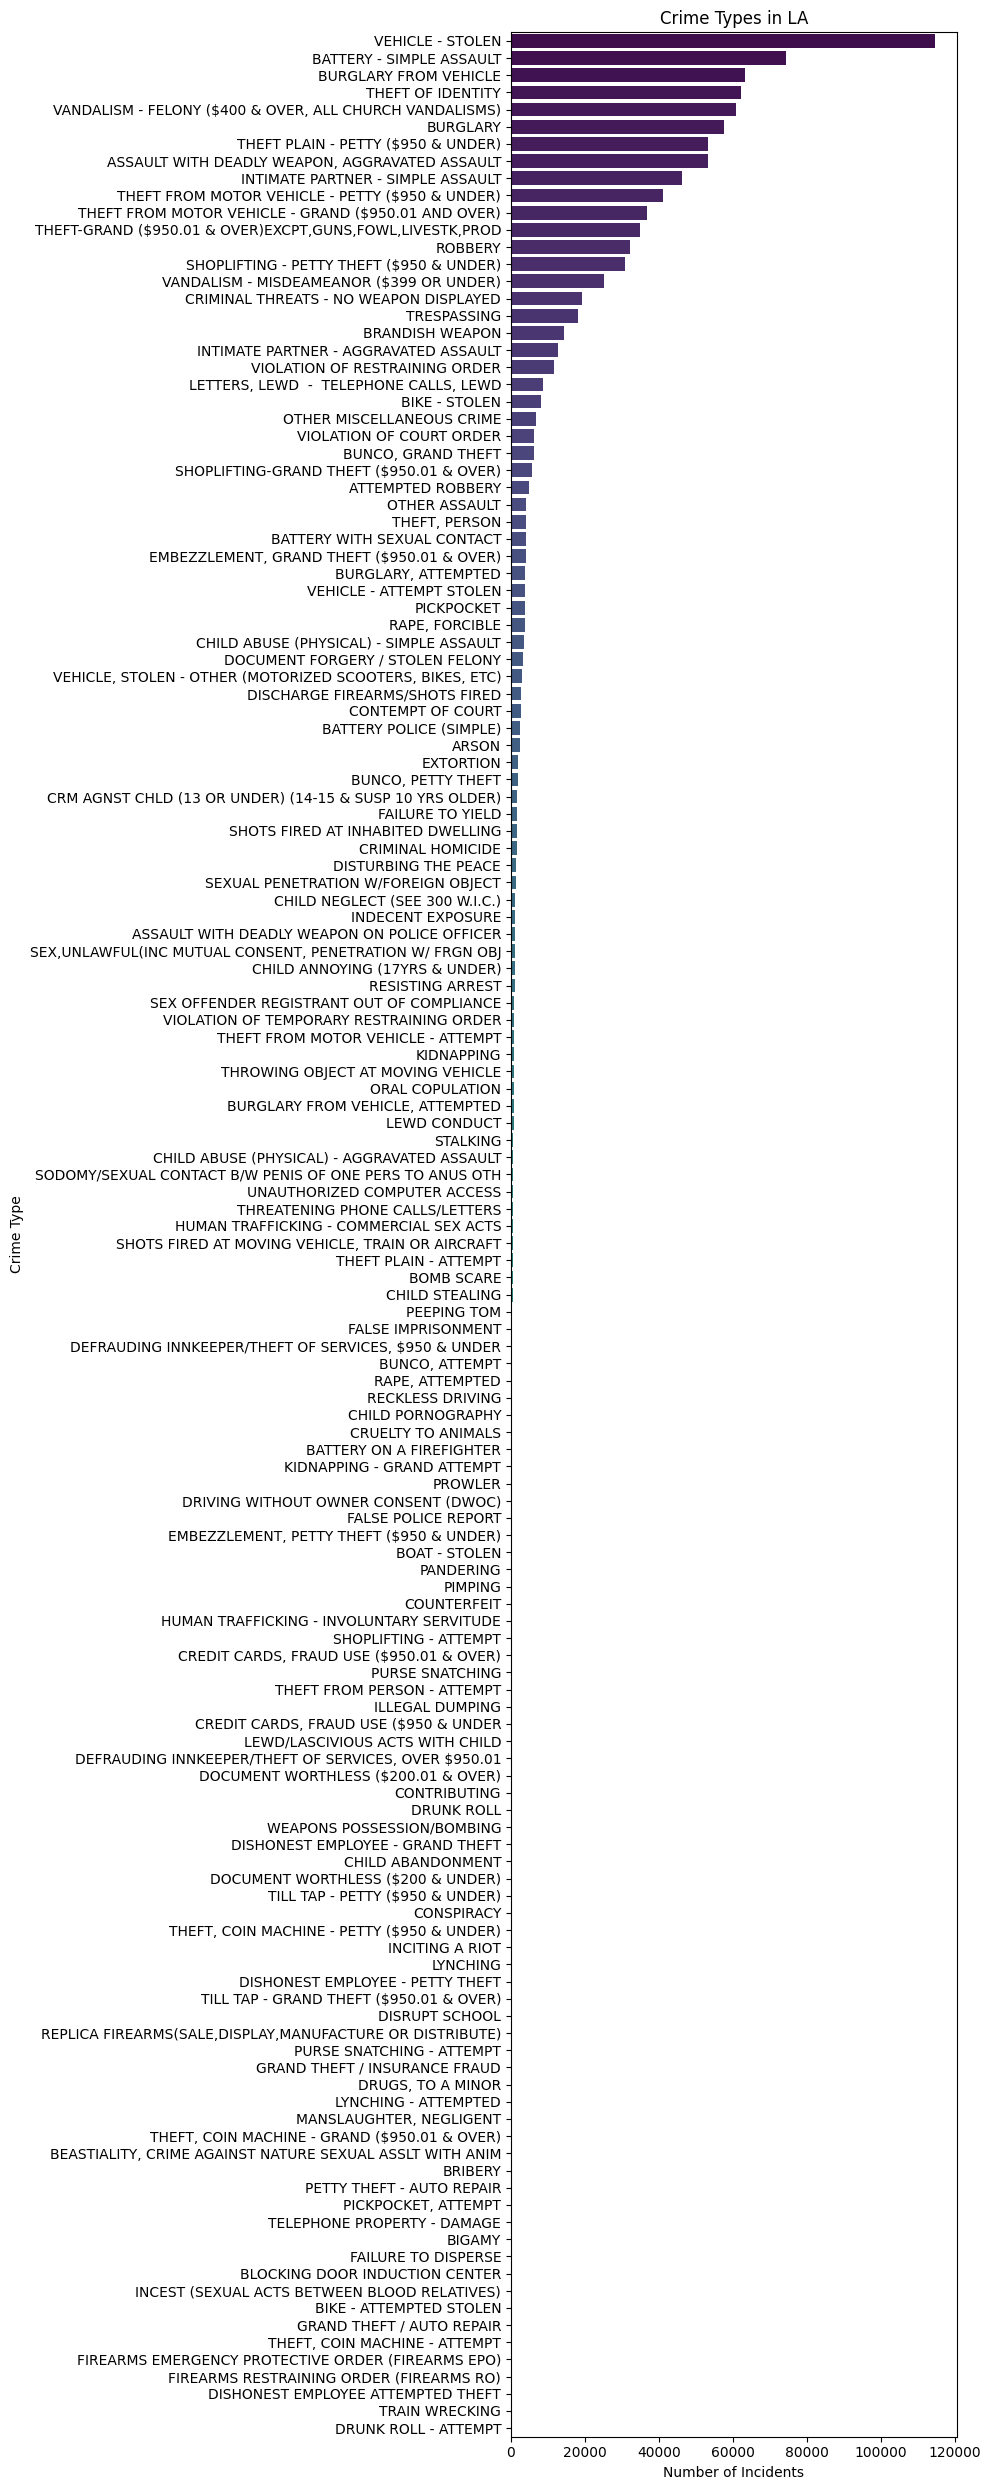

In [39]:
# number of times crimes happend
top_crimes = df['Crm Cd Desc'].value_counts()

plt.figure(figsize=(10,25))
sns.barplot(x=top_crimes.values, y=top_crimes.index, palette="viridis")
plt.title("Crime Types in LA")
plt.xlabel("Number of Incidents")
plt.ylabel("Crime Type")
plt.tight_layout()
plt.show()

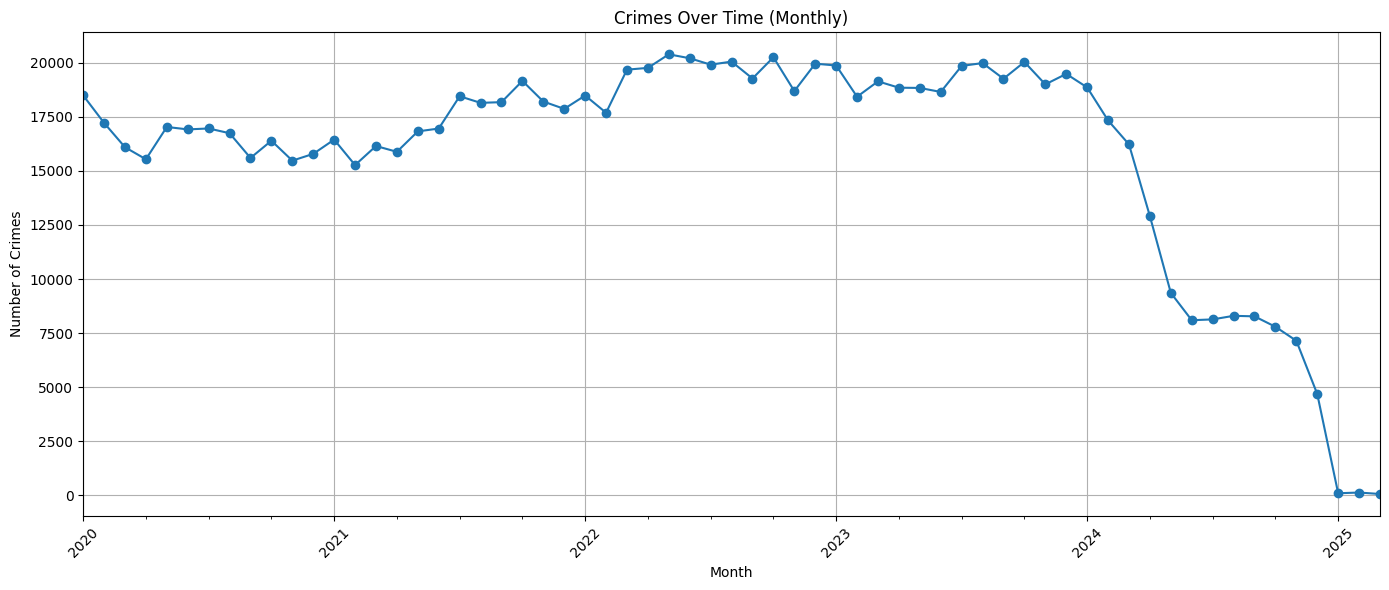

In [40]:
# Number of crimes each month
df['YearMonth'] = df['DateTime OCC'].dt.to_period('M')
crime_over_time = df.groupby('YearMonth').size()

plt.figure(figsize=(14,6))
crime_over_time.plot(kind='line', marker='o')
plt.title("Crimes Over Time (Monthly)")
plt.xlabel("Month")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

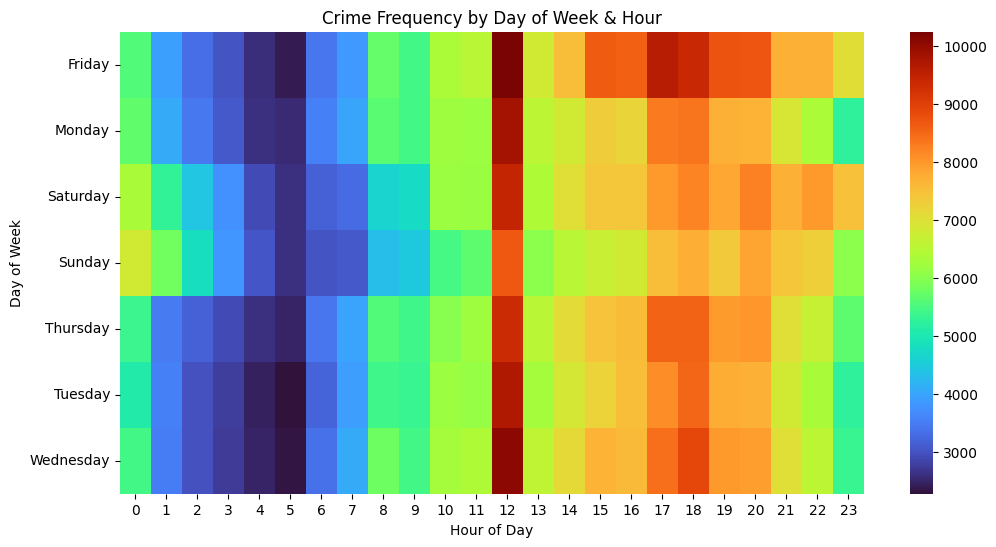

In [41]:
# Crime Frequency by Day of Week & Hour
df['DayOfWeek'] = df['DateTime OCC'].dt.day_name()
df['Hour'] = df['DateTime OCC'].dt.hour

heat_data = df.groupby(['DayOfWeek','Hour']).size().unstack(fill_value=0)

plt.figure(figsize=(12,6))
sns.heatmap(heat_data, cmap="turbo")
plt.title("Crime Frequency by Day of Week & Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.show()

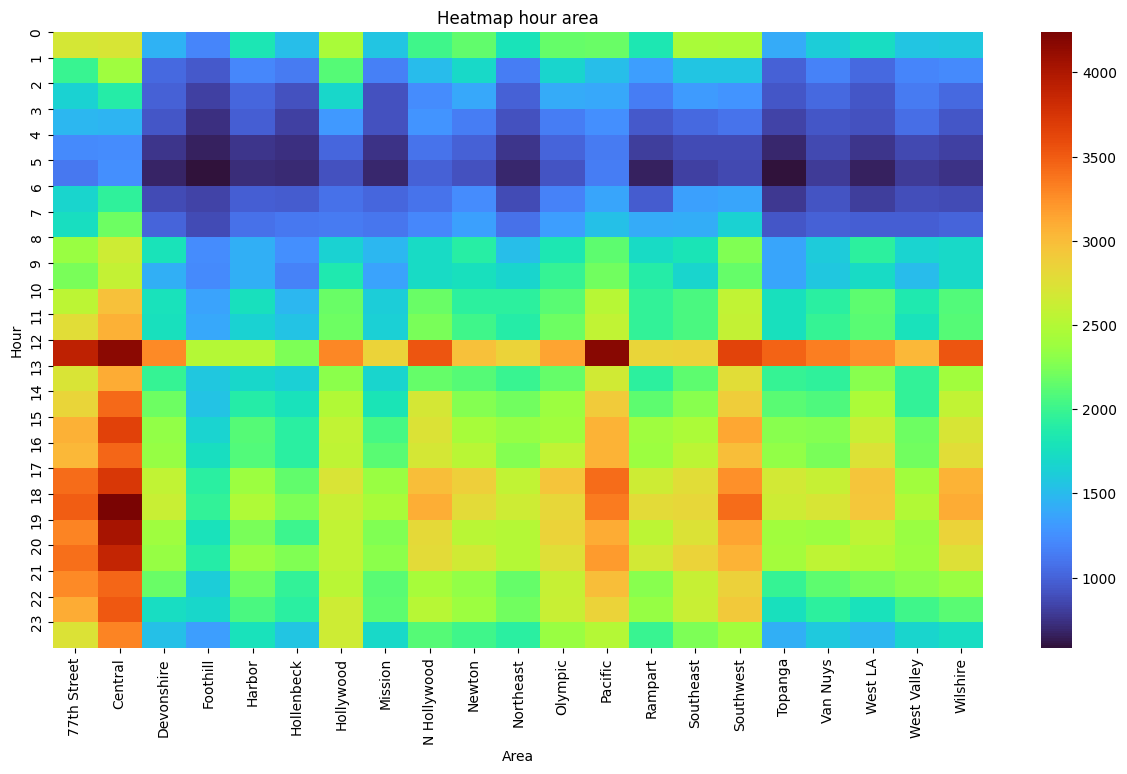

In [42]:
# Heatmap hour area
crime_by_time_type = df.groupby(['Hour', 'AREA NAME'])['Crm Cd Desc'].count().unstack()    

plt.figure(figsize=(15, 8))
sns.heatmap(crime_by_time_type.fillna(0), cmap='turbo', annot=False)
plt.title('Heatmap hour area')
plt.xlabel('Area')
plt.ylabel('Hour')
plt.yticks(range(24), range(24))  #
plt.show()

In [43]:
# remove the help features
df = df.drop(columns=['YearMonth', 'DayOfWeek', 'Hour'])

Next we export the data as json.

In [44]:
df['DateTime OCC'] = df['DateTime OCC'].dt.strftime('%Y-%m-%d %H:%M:%S')

In [45]:
df.to_json("data.json", orient="records")